In [1]:
# -------------------------
# 1. Import Required Libraries
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# ------------------------------------------------------------
# 2. Load the Iris Dataset
# ------------------------------------------------------------
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target labels
df["species"] = iris.target

# Convert numeric labels into species names
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("="*60)
print("First Five Records")
print("="*60)
print(df.head())

First Five Records
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [3]:
# Add target column
df['species'] = iris.target

# Convert numeric labels to species names
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Display first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:

# ------------------------------------------------------------
# 3. Exploratory Data Analysis (EDA)
# ------------------------------------------------------------

print("\n")
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")
print("="*60)
print("Data Types")
print("="*60)
print(df.dtypes)

print("\n")
print("="*60)
print("Missing Values")
print("="*60)
print(df.isnull().sum())

print("\n")
print("="*60)
print("Summary Statistics")
print("="*60)
print(df.describe())

print("\n")
print("="*60)
print("Species Distribution")
print("="*60)
print(df["species"].value_counts())



Dataset Shape
(150, 5)


Data Types
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


Summary Statistics
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  

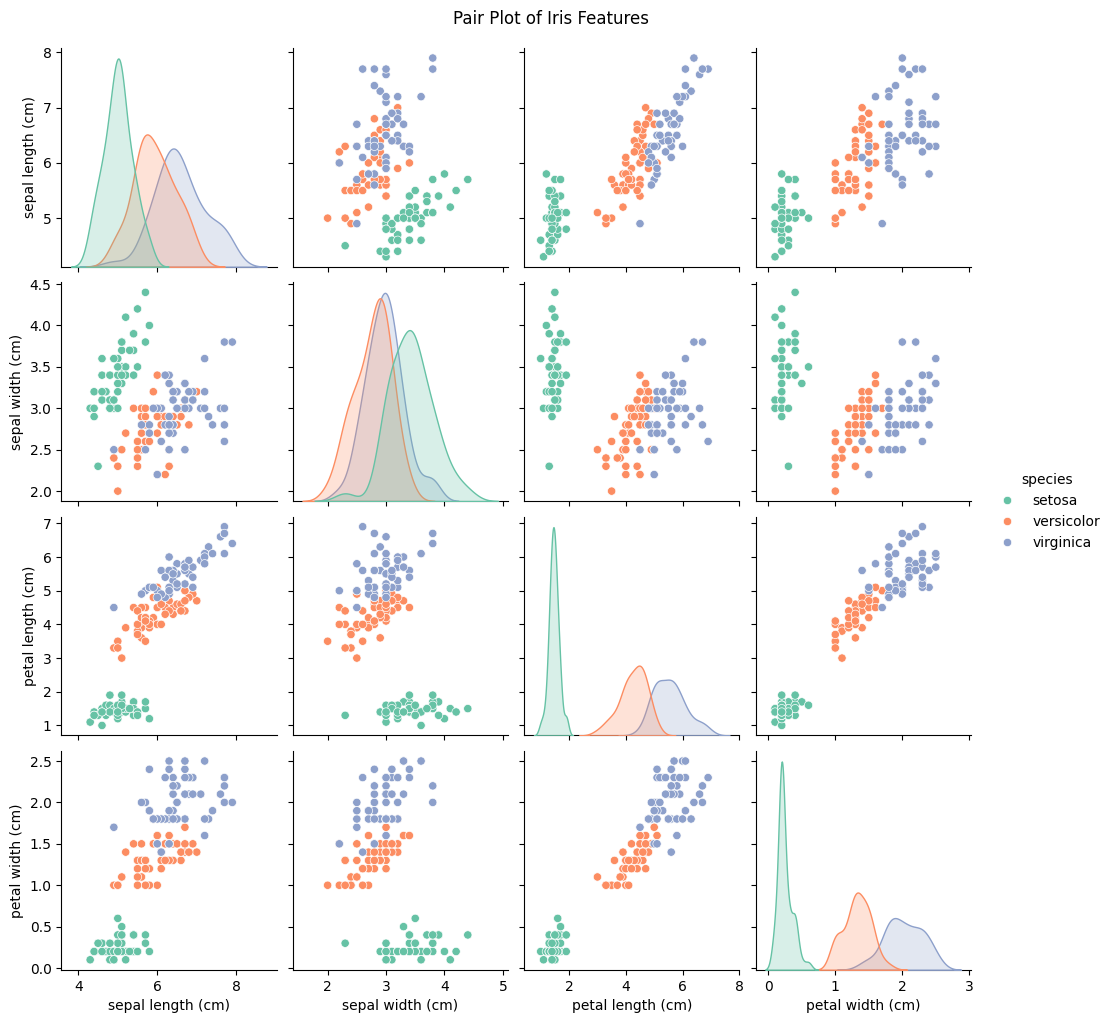

In [4]:
# ------------------------------------------------------------
# 4. Pair Plot
# ------------------------------------------------------------

sns.pairplot(
    df,
    hue="species",
    palette="Set2"
)

plt.suptitle("Pair Plot of Iris Features", y=1.02)
plt.show()

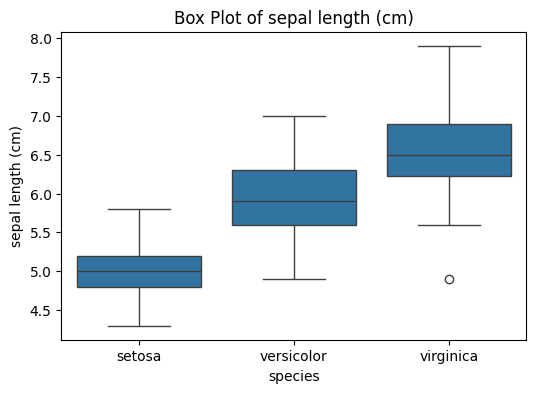

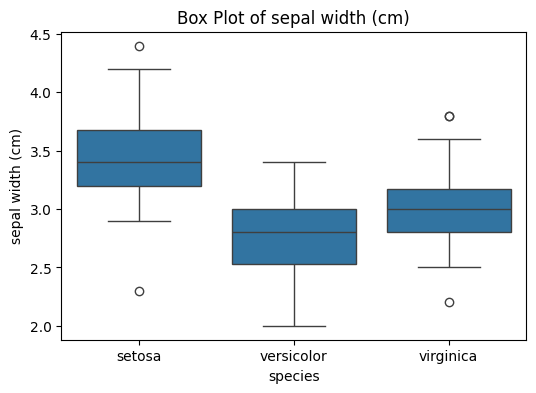

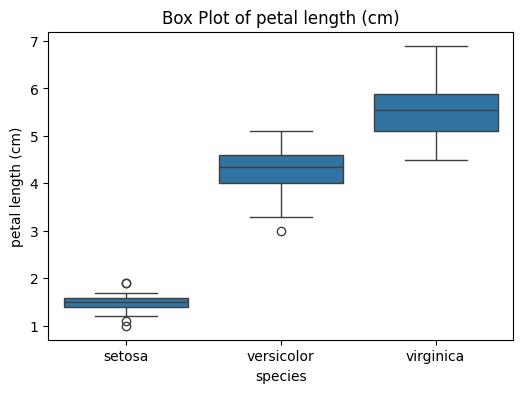

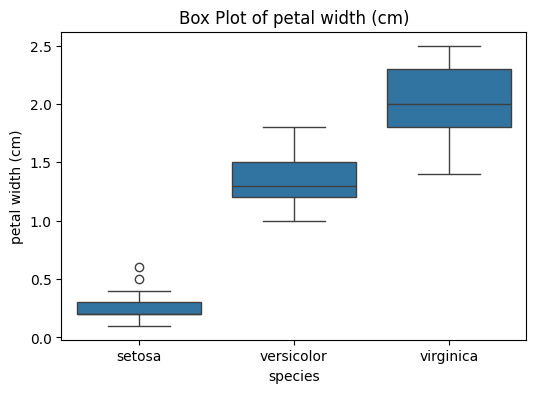

In [5]:
# ------------------------------------------------------------
# 5. Box Plots
# ------------------------------------------------------------

for feature in iris.feature_names:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="species",
        y=feature,
        data=df
    )

    plt.title(f"Box Plot of {feature}")

    plt.show()

In [6]:
# ------------------------------------------------------------
# 6. Feature Selection Discussion
# ------------------------------------------------------------

print("\n")
print("="*60)
print("Feature Selection Discussion")
print("="*60)

print("""
From the pair plots and box plots:

• Petal Length
• Petal Width

are the most discriminative features because they clearly
separate the three iris species.

Sepal Length and Sepal Width show greater overlap,
making them less useful for classification.
""")




Feature Selection Discussion

From the pair plots and box plots:

• Petal Length
• Petal Width

are the most discriminative features because they clearly
separate the three iris species.

Sepal Length and Sepal Width show greater overlap,
making them less useful for classification.



In [7]:
# ------------------------------------------------------------
# 7. Prepare Features and Target
# ------------------------------------------------------------

X = df.drop("species", axis=1)
y = df["species"]


In [8]:
# ------------------------------------------------------------
# 8. Train-Test Split (80/20)
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("="*60)


Training Samples : 120
Testing Samples  : 30


In [9]:
# ------------------------------------------------------------
# 9. Train Models
# ------------------------------------------------------------

# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [10]:
# ------------------------------------------------------------
# 10. Model Evaluation Function
# ------------------------------------------------------------

def evaluate_model(model_name, y_true, predictions):

    print("\n")
    print("="*60)
    print(model_name)
    print("="*60)

    accuracy = accuracy_score(y_true, predictions)

    print("Accuracy :", round(accuracy*100,2), "%")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, predictions))

    print("\nClassification Report")
    print(classification_report(y_true, predictions))

    return accuracy


In [11]:
# ------------------------------------------------------------
# 11. Evaluate Models
# ------------------------------------------------------------

lr_accuracy = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

knn_accuracy = evaluate_model(
    "K-Nearest Neighbours",
    y_test,
    knn_pred
)

dt_accuracy = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

rf_accuracy = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)



Logistic Regression
Accuracy : 96.67 %

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



K-Nearest Neighbours
Accuracy : 100.0 %

Confusion Matrix
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


In [12]:

# ------------------------------------------------------------
# 12. Compare Model Performance
# ------------------------------------------------------------

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy
    ]

})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*60)
print("Model Comparison")
print("="*60)
print(results)




Model Comparison
                 Model  Accuracy
1                  KNN  1.000000
0  Logistic Regression  0.966667
2        Decision Tree  0.933333
3        Random Forest  0.900000


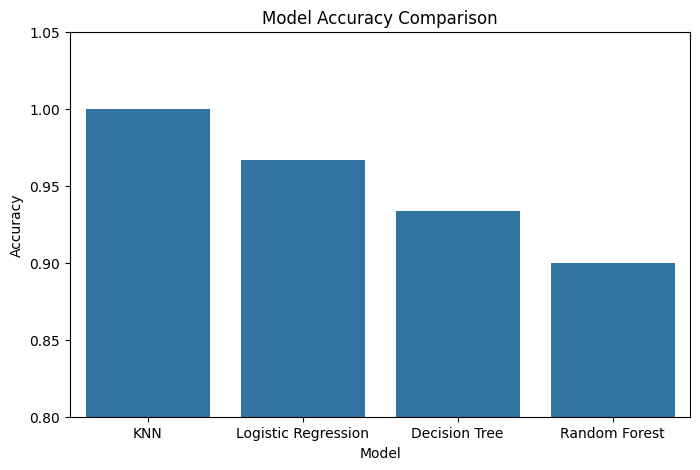

In [13]:
# ------------------------------------------------------------
# 13. Accuracy Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.8,1.05)

plt.show()